# Case 2a Preliminary -- Half-Max Velocity (Maize Primary Root)

**Dissertation Chapter 6, Section 6.2.1, "Local Changes in Relative Cross-Section Area" (p. 111):**

> To further investigate this, TACs were derived from four ROIs along the lower segment of a
> maize primary root. The decay-corrected TACs showed increasing temporal spacing at later time
> points, indicating a deceleration of the tracer front (Figure fig:area_change_hmax a).
>
> As a first step, the data were analyzed using the half-maximum method. The fit to the
> distance-time data yielded a velocity of 3.11 +/- 6.1% with a very high coefficient of
> determination (R^2 = 0.99) and low relative uncertainty, which could be interpreted as evidence
> of constant velocity. However, closer inspection of the fit (Figure fig:area_change_hmax b)
> shows a subtle but systematic downward deviation of the data points, which could hint to a
> velocity decrease as well.

Preliminary analysis preceding the main MCT fit (`case2a_local_velocity_change_maize_root.ipynb`).
Reproduces the `fig:area_change_hmax` half-max/distance-time-fit panels.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
from scipy import stats
import seaborn as sns

from scipy import interpolate

import sys; sys.path.insert(0, "..")
from utils import *

In [2]:
import os
os.makedirs("output/figures", exist_ok=True)


In [3]:
df = pd.read_csv("data/case2a_maize_root.csv", index_col=0)

In [4]:
xi=list(df.columns)
t=df.index.to_numpy()

data_cor=df[xi].to_numpy(dtype=float)

data_unc=df[xi].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

steps=len(data_cor)

d_xi=[]

for i in range(1,len(xi)):
     d_xi.append(float(xi[i])-float(xi[i-1]))

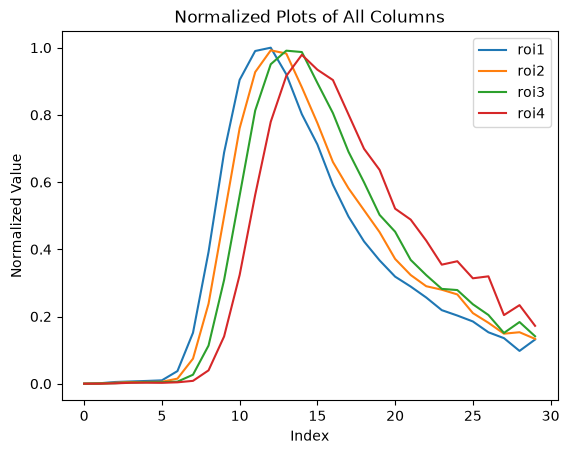

In [6]:
rois = plot_all_columns(data_cor[:, 11:15])


In [7]:
xi=xi[11:15]

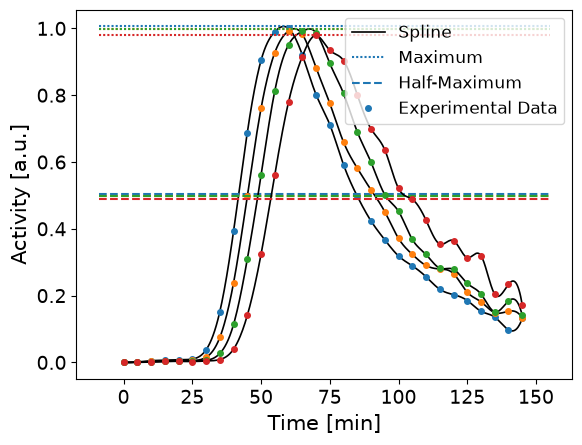

In [8]:
results = process_and_plot_rois(rois, t, savefig_name="output/figures/local_velocity_change_hmax.pdf")


In [9]:
hmaxi = np.array(list(compute_hmax_times(results,np.linspace(0,145,500)).values()))

In [10]:
points=np.array(xi[:], dtype="float")

[3.11101999 1.58215304] 0.1919971721840206


np.float64(0.9924400600900326)

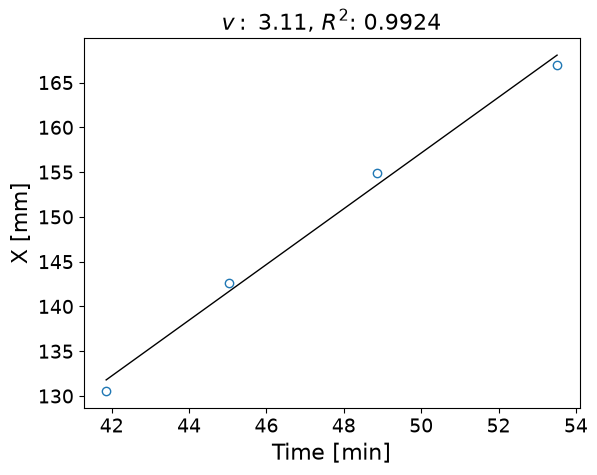

In [11]:
points=np.array(xi, dtype="float")

Iv=np.ones((len(hmaxi),1))
Mv=np.array(np.append(Iv,hmaxi.reshape(len(hmaxi),1),axis=1))

mbinter_v=np.array([]).reshape(0,3)
b1v, m1v = lstsq(Mv, points)[0]
mbinter_v = np.vstack((mbinter_v, (m1v, b1v, -b1v/m1v)))

plt.style.use('default')
    
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 

for i in range (0,len(mbinter_v)):
    plt.plot(hmaxi, mbinter_v[i][0]*np.array(hmaxi)+mbinter_v[i][1], label=np.round(mbinter_v[i][0],3),color='k', linewidth=1)    
    

    
#np.polyfit(intercepts,points,1)
plt.plot(hmaxi, points, marker='o', linestyle='None',markerfacecolor='none')

plt.xlabel("Time [min]",fontsize=16)
plt.ylabel("X [mm]",fontsize=16)
plt.title(f"$v:$ {np.around(mbinter_v[0][0],2)}, $R^2$: {np.around(np.corrcoef(hmaxi, points)[0,1]**2, 4)}", fontsize=16)
np.corrcoef(hmaxi, points)[0,1]**2

plt.savefig("output/figures/local_velocity_change_hmaxfit.pdf", format="pdf")  
fit, V=np.polyfit(hmaxi,points,1, cov=True)
print(fit,np.sqrt(V[0][0]))

np.corrcoef(hmaxi, points)[0,1]**2